In [1]:
################################### Notebook Details ####################################
#
# In this Notebook:
#   - we analyze a two node coupled system dynamics with by varying coupling coefficient while keeping external input at a constant;
#   - coupling value is varied from -1 to +1 (both inhibitory and excitatory coupling);
#   - analyze the effect of heterogeneity on stability and robustness of the coupled system. 

In [2]:
import os
import json
import time
import random
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt

from scipy import signal, linalg
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp

from utils import *
from plot_utils import *
from measure_utils import *

%matplotlib inline
plt.rcParams.update({'font.size': 16})

In [3]:
COLOR_MAP = {
                'mediumblue': "Unstable Node",
                'darkgreen': "Stable Node",
                'red': "Unstable Saddle Point",
                'saddlebrown': "Stable Spiral",
                'purple': "Unstable Spiral",
                'black': "Circle"
            }

In [4]:
# Setting save dir paths
root_dir = "./sv_coupled_model"

save_str = datetime.datetime.now()
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}-{save_str.strftime('%H')}-{save_str.strftime('%M')}"

save_dir = os.path.join(root_dir, sub_dir)

print(f"Creating dir to save results:: {save_dir}")
os.makedirs(save_dir, exist_ok = True)

write_json = {}

Creating dir to save results:: ./sv_coupled_model\exp-2023-11-8-08-14


In [5]:
params = { }

params['gamma'] = gamma = 0.016

params['sig_e1'] = sig_e1 = 8.5
params['sig_i1'] = sig_i1 = 16.5
params['sig_e2'] = sig_e2 = 4.4
params['sig_i2'] = sig_i2 = 2.5

params['K'] = K = 0.2
params['D'] = D = 0.001
params['dt'] = dt = 0.1
params['Ne'] = Ne = 800
params['Ni'] = Ni = 200

params['beta'] = beta = 300 * params['gamma']
params['theta'] = theta = 0.0
params['tau_e'] = tau_e = 1
params['tau_i'] = tau_i = 1 / 2

params['wee'] = wee = 1.6 / params['gamma']
params['wei'] = wei = 3.0 / params['gamma']
params['wie'] = wie = -4.7 / params['gamma']
params['wii'] = wii = -0.13 / params['gamma']

params['i_e1'] = i_e1 = 0.25 / params['gamma']
params['i_i1'] = i_i1 = -0.5 / params['gamma']
params['i_e2'] = i_e2 = -0.25 / params['gamma']
params['i_i2'] = i_i2 = -0.5 / params['gamma']

In [6]:
T = 2500
time_ = np.arange(0, T)

# grid parameters
minval = -1 / params['gamma']
maxval = 1 / params['gamma']
grid_res = 20
n_trials = 5

# Numerical ODE integration to plot trajectories
x0_ = np.random.uniform(minval, maxval, n_trials)
x1_ = np.random.uniform(minval, maxval, n_trials)
x2_ = np.random.uniform(minval, maxval, n_trials)
x3_ = np.random.uniform(minval, maxval, n_trials)

# image_counters
ts_image = 0
spec_rad_image = 0
lyap_node = 0
lyap_net = 0

In [7]:
def euler_intergrate(u, **opts):
    # common parameters
    sig_e1 = opts.get('sig_e1')
    sig_e2 = opts.get('sig_e2')
    sig_i1 = opts.get('sig_i1')
    sig_i2 = opts.get('sig_i2')
    
    print('running euler intergration')
    for k, y0 in enumerate(zip(x0_, x1_, x2_, x3_)):
            # initialize with the points
            u[k, :, 0] = y0
            for t in range(T - 1):
                u[k, 0, t + 1] = u[k, 0, t] + dt / tau_e * \
                                 (-u[k, 0, t] + wee * F(u[k, 0, t], beta, theta, gamma, sig_e1) + wie * F(u[k, 1, t], beta, theta, gamma, sig_i1) + opts['i_e1'] + opts['K'] * u[k, 2, t])
                u[k, 1, t + 1] = u[k, 1, t] + dt / tau_i * \
                                 (-u[k, 1, t] + wei * F(u[k, 0, t], beta, theta, gamma, sig_e1) + wii * F(u[k, 1, t], beta, theta, gamma, sig_i1) + i_i1)
                u[k, 2, t + 1] = u[k, 2, t] + dt / tau_e * \
                                 (-u[k, 2, t] + wee * F(u[k, 2, t], beta, theta, gamma, sig_e2) + wie * F(u[k, 3, t], beta, theta, gamma, sig_i2) +\
                                  i_e2 + opts['K'] * u[k, 0, t])
                u[k, 3, t + 1] = u[k, 3, t] + dt / tau_i * \
                                 (-u[k, 3, t] + wei * F(u[k, 2, t], beta, theta, gamma, sig_e2) + wii * F(u[k, 3, t], beta, theta, gamma, sig_i2) + i_i2)
    return u

In [8]:
fp_dict = calc_fixed_points(
                            minval = minval,
                            maxval = maxval,
                            grid_res = grid_res,
                            n_init = 20,
                            cal_grad = True,
                            **params
                            )

eig_dict = calc_jacobian(fp_dict['fps'].T, **params)

u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, **params)

C:\Users\kgaya\OneDrive - University of Toronto\University of Toronto\MASc Research Project\#03 Implementation\Heterogeneity Spike Model\SVSystemAnalysis\sv_two_node_analysis\utils.py:19: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * (x - thresh)))


calculating gradients for the system...


C:\Users\kgaya\OneDrive - University of Toronto\University of Toronto\MASc Research Project\#03 Implementation\Heterogeneity Spike Model\SVSystemAnalysis\sv_two_node_analysis\utils.py:144: RuntimeWarning: overflow encountered in square
  return beta * np.exp(-beta * (x - theta)) / ((1 + np.exp(-beta * (x - theta))) ** 2)


running euler intergration


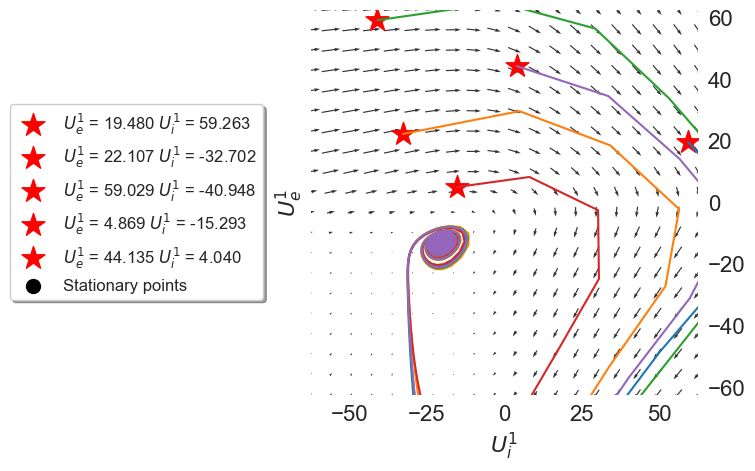

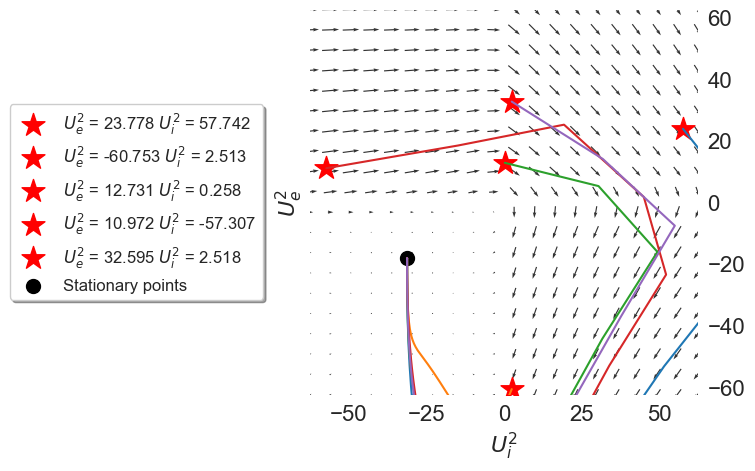

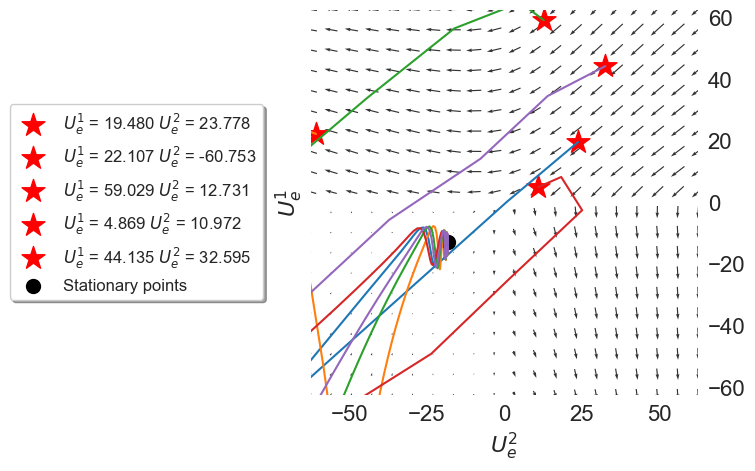

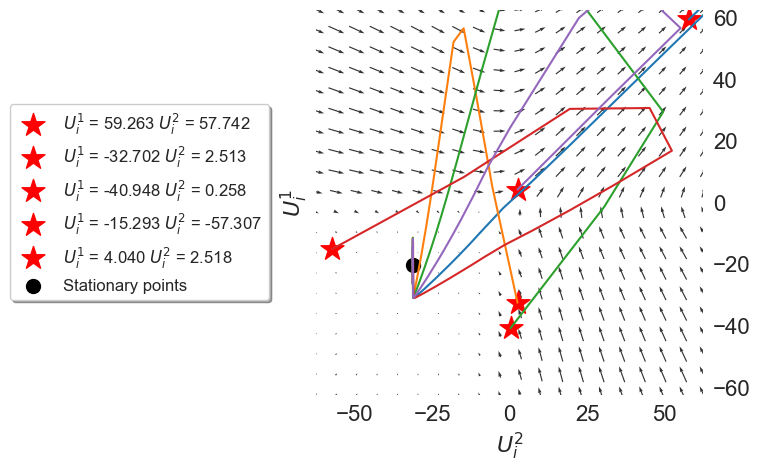

In [9]:
# plot e1 vs. i1
plot_trajectory(
                minval = minval,
                maxval = maxval,
                ode_solves = u,
                init_points = [x0_, x1_, x2_, x3_],
                plot_dim = [0, 1],
                fig_size = (5, 5),
                **fp_dict
                )

# plot e2 vs. i2
plot_trajectory(
                minval = minval,
                maxval = maxval,
                ode_solves = u,
                init_points = [x0_, x1_, x2_, x3_],
                plot_dim = [2, 3],
                fig_size = (5, 5),
                **fp_dict
                )

# plot e1 vs. e2
plot_trajectory(
                minval = minval,
                maxval = maxval,
                ode_solves = u,
                init_points = [x0_, x1_, x2_, x3_],
                plot_dim = [0, 2],
                fig_size = (5, 5),
                **fp_dict
                )

# plot i1 vs. i2
plot_trajectory(
                minval = minval,
                maxval = maxval,
                ode_solves = u,
                init_points = [x0_, x1_, x2_, x3_],
                plot_dim = [1, 3],
                fig_size = (5, 5),
                **fp_dict
                )

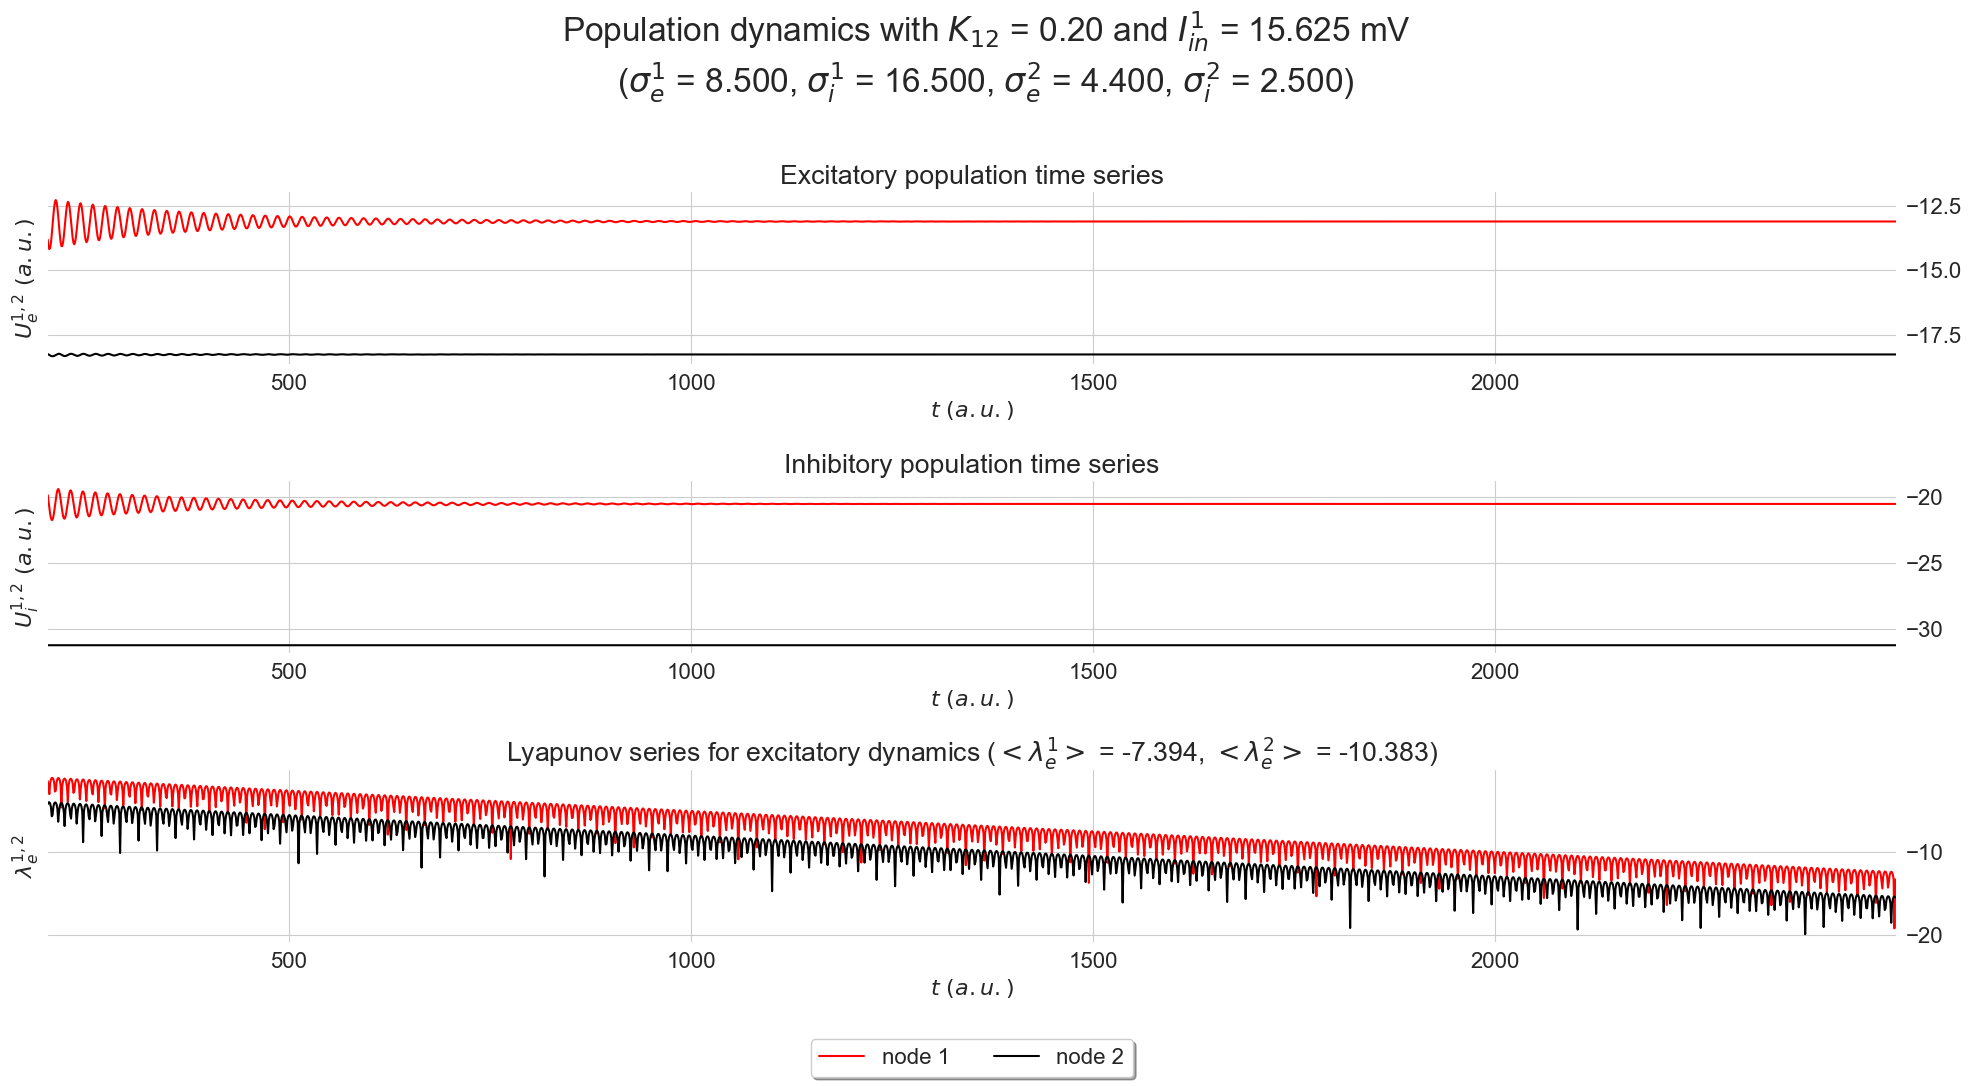

In [10]:
plot_ts(
        u = u,
        t_arr = time_,
        t1 = 200,
        t2 = T,
        fig_size = (20, 12),
        if_save = True, 
        save_dir = save_dir,
        image_name = f'ts_image_{ts_image:03d}',
        **params
        )

ts_image += 1

C:\Users\kgaya\OneDrive - University of Toronto\University of Toronto\MASc Research Project\#03 Implementation\Heterogeneity Spike Model\SVSystemAnalysis\sv_two_node_analysis\measure_utils.py:60: RuntimeWarning: invalid value encountered in sqrt
  ax.plot(x, np.sqrt(spect_radius ** 2 - (x - spect_center.real) ** 2), color=color_rads)
C:\Users\kgaya\OneDrive - University of Toronto\University of Toronto\MASc Research Project\#03 Implementation\Heterogeneity Spike Model\SVSystemAnalysis\sv_two_node_analysis\measure_utils.py:61: RuntimeWarning: invalid value encountered in sqrt
  ax.plot(x, -np.sqrt(spect_radius ** 2 - (x - spect_center.real) ** 2), color=color_rads)


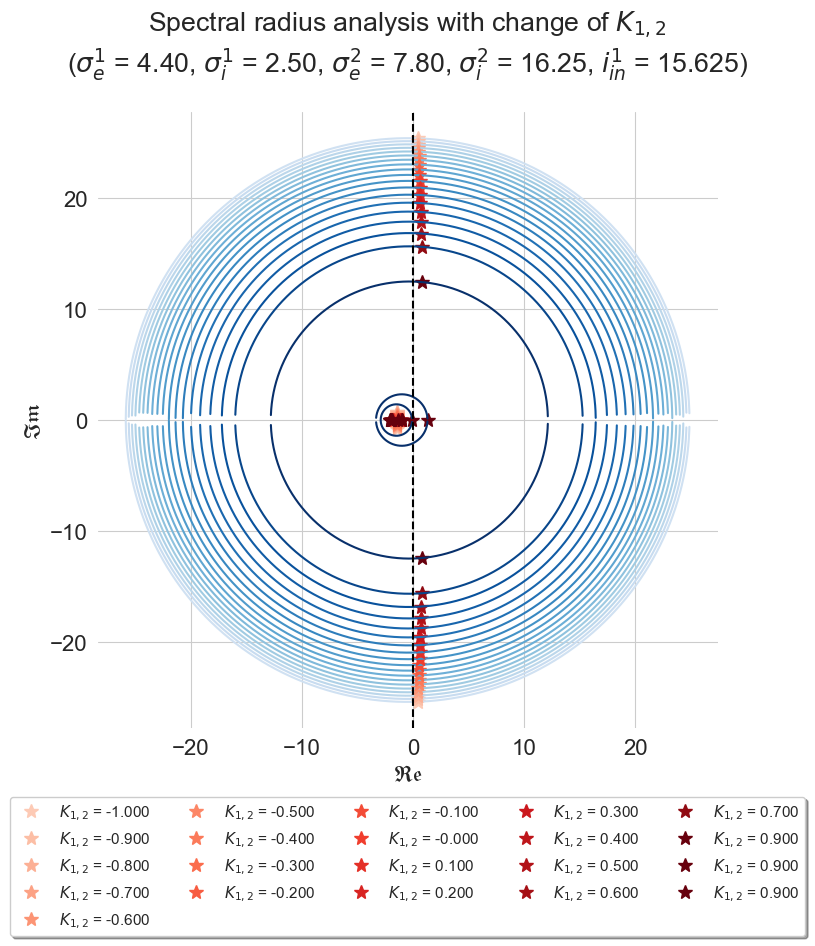

In [11]:
# change with coupling value

params['i_e1'] = 0.25 / params['gamma']
params['sig_e1'] = 4.4
params['sig_i1'] = 2.5
params['sig_e2'] = 7.8
params['sig_i2'] = 16.25

para_str =  r'($\sigma_e^1$ = ' + f"{params['sig_e1']:.2f}, " +\
            r'$\sigma_i^1$ = ' + f"{params['sig_i1']:.2f}, " +\
            r'$\sigma_e^2$ = ' + f"{params['sig_e2']:.2f}, " +\
            r'$\sigma_i^2$ = ' + f"{params['sig_i2']:.2f}, " +\
            r'$i_{in}^1$ = ' + f"{params['i_e1']:.3f})"

spectral_rad_analysis(
                      var_min = -1, 
                      var_max = 1, 
                      d_var = 0.1, 
                      var_name = 'K', 
                      plot_opts = {'fig_size': (8, 8), 'label_tag': r"$K_{1,2}$", 'para_str': para_str}, 
                      if_save = True, 
                      save_dir = save_dir, 
                      image_name = f'spec_rad_image_{spec_rad_image:03d}', 
                      **params
                      )

spec_rad_image += 1

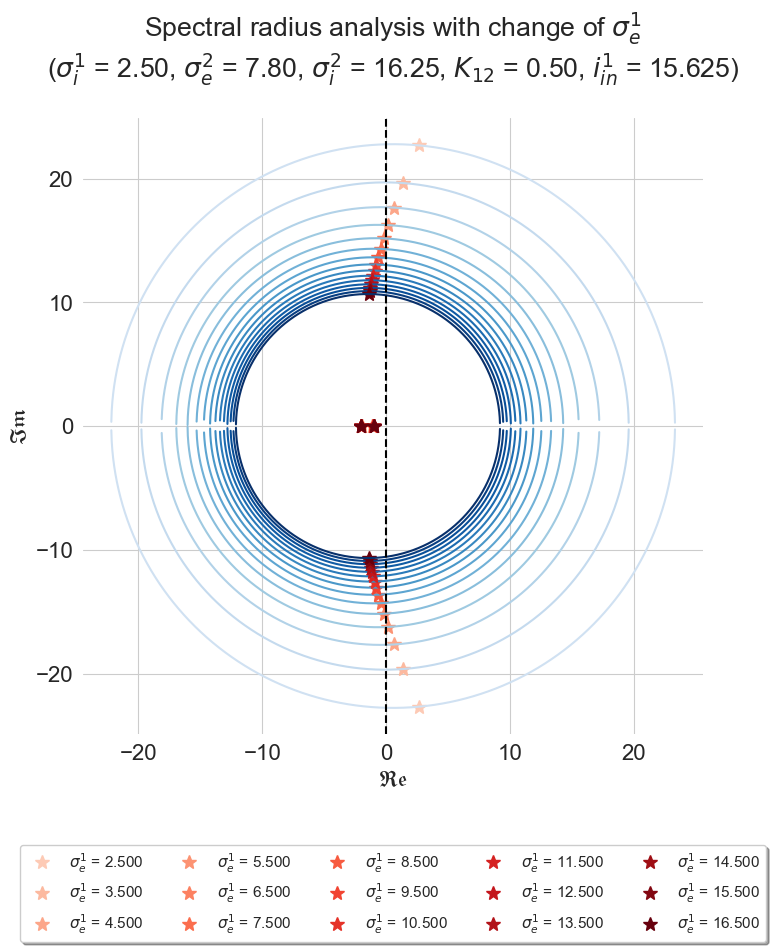

In [12]:
params['K'] = 0.5
params['sig_i1'] = 2.5
params['i_e1'] = 0.25 / params['gamma']
params['sig_e2'] = 7.8
params['sig_i2'] = 16.25

para_str =  r'($\sigma_i^1$ = ' + f"{params['sig_i1']:.2f}, " +\
            r'$\sigma_e^2$ = ' + f"{params['sig_e2']:.2f}, " +\
            r'$\sigma_i^2$ = ' + f"{params['sig_i2']:.2f}, " +\
            r'$K_{12}$ = ' + f"{params['K']:.2f}, " +  r'$i_{in}^1$ = ' + f"{params['i_e1']:.3f})"

spectral_rad_analysis(
                      var_min = 2.5, 
                      var_max = 17.5, 
                      d_var = 1, 
                      var_name = 'sig_e1', 
                      plot_opts = {'fig_size': (8, 8), 'label_tag': r"$\sigma_e^1$", 'para_str': para_str}, 
                      if_save = True, 
                      save_dir = save_dir, 
                      image_name = f'spec_rad_image_{spec_rad_image:03d}', 
                      **params
                      )

spec_rad_image += 1

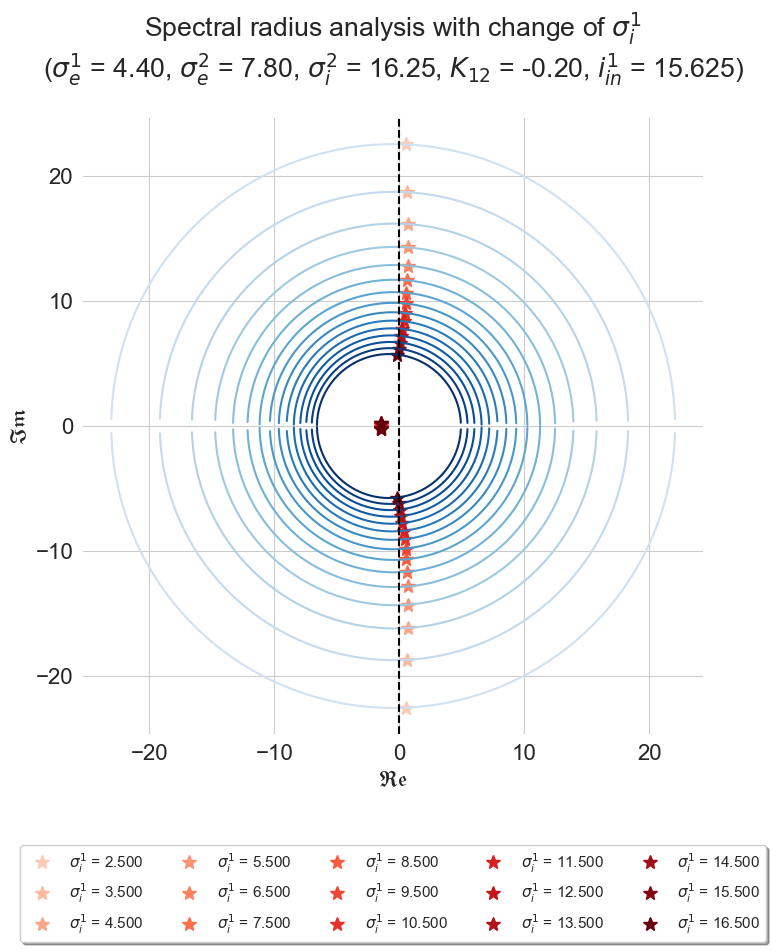

In [13]:
params['K'] = -0.2
params['sig_e1'] = 4.4
params['i_e1'] = 0.25 / params['gamma']
params['sig_e2'] = 7.8
params['sig_i2'] = 16.25

para_str =  r'($\sigma_e^1$ = ' + f"{params['sig_e1']:.2f}, " +\
            r'$\sigma_e^2$ = ' + f"{params['sig_e2']:.2f}, " +\
            r'$\sigma_i^2$ = ' + f"{params['sig_i2']:.2f}, " +\
            r'$K_{12}$ = ' + f"{params['K']:.2f}, " +  r'$i_{in}^1$ = ' + f"{params['i_e1']:.3f})"

spectral_rad_analysis(
                      var_min = 2.5, 
                      var_max = 17.5, 
                      d_var = 1, 
                      var_name = 'sig_i1', 
                      plot_opts = {'fig_size': (8, 8), 'label_tag': r"$\sigma_i^1$", 'para_str': para_str}, 
                      if_save = True, 
                      save_dir = save_dir, 
                      image_name = f'spec_rad_image_{spec_rad_image:03d}', 
                      **params
                      )

spec_rad_image += 1

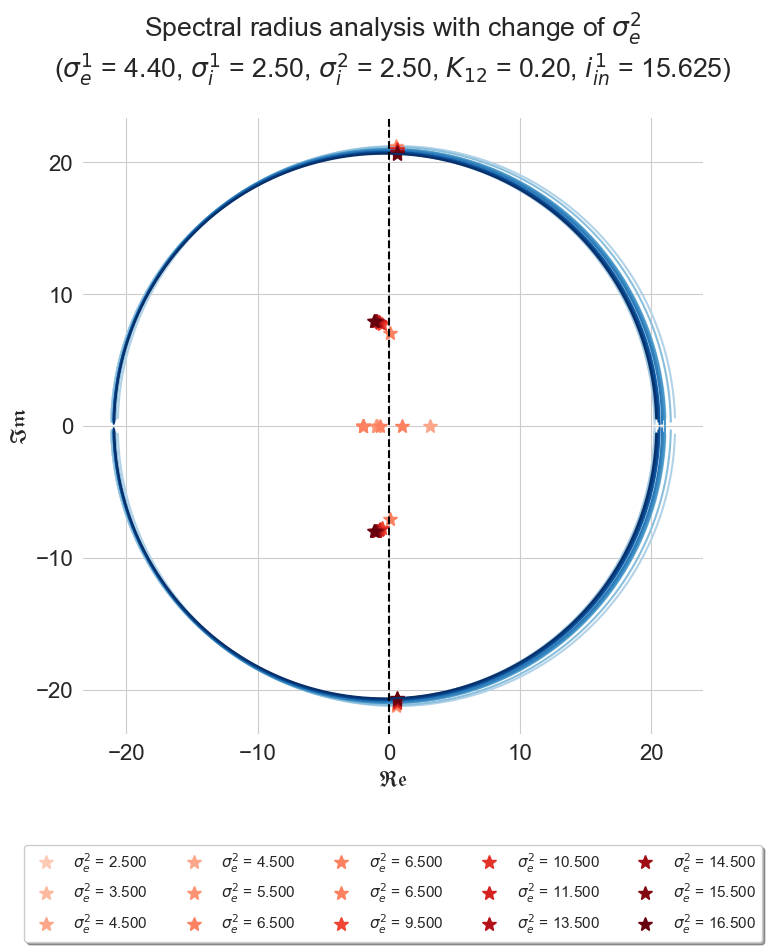

In [14]:
params['K'] = 0.2
params['sig_e1'] = 4.4
params['sig_i1'] = 2.5
params['sig_i2'] = 2.5
params['i_e1'] = 0.25 / params['gamma']

para_str =  r'($\sigma_e^1$ = ' + f"{params['sig_e1']:.2f}, " +\
            r'$\sigma_i^1$ = ' + f"{params['sig_i1']:.2f}, " +\
            r'$\sigma_i^2$ = ' + f"{params['sig_i2']:.2f}, " +\
            r'$K_{12}$ = ' + f"{params['K']:.2f}, " +  r'$i_{in}^1$ = ' + f"{params['i_e1']:.3f})"

spectral_rad_analysis(
                      var_min = 2.5, 
                      var_max = 17.5, 
                      d_var = 1, 
                      var_name = 'sig_e2', 
                      plot_opts = {'fig_size': (8, 8), 'label_tag': r"$\sigma_e^2$", 'para_str': para_str}, 
                      if_save = True, 
                      save_dir = save_dir, 
                      image_name = f'spec_rad_image_{spec_rad_image:03d}', 
                      **params
                      )

spec_rad_image += 1

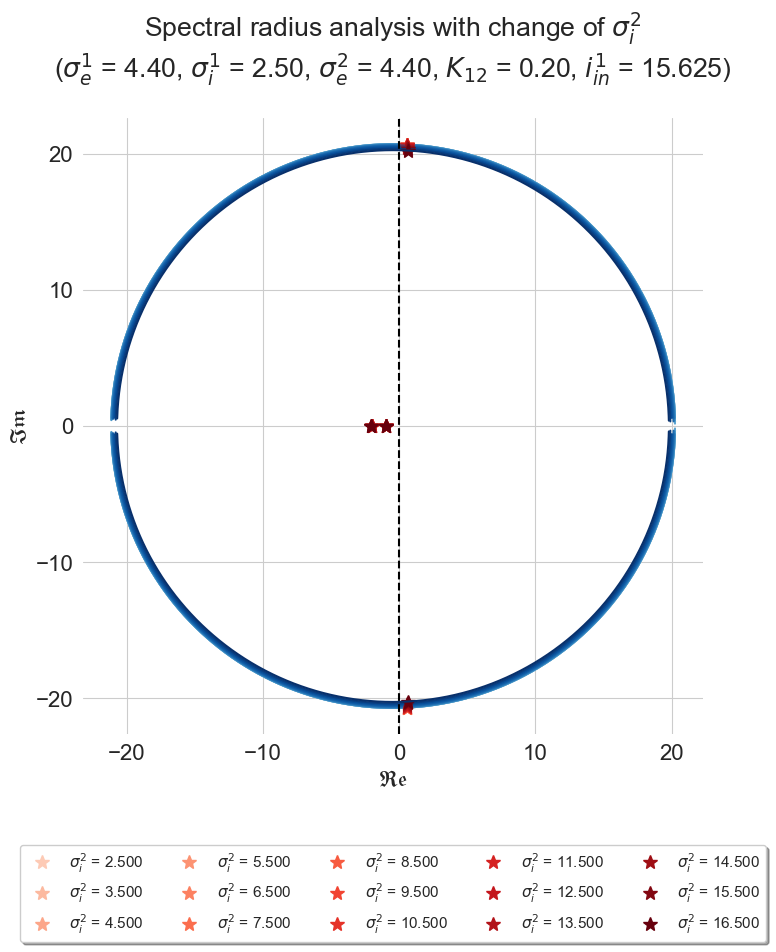

In [15]:
params['K'] = 0.2
params['sig_e1'] = 4.4
params['sig_i1'] = 2.5
params['sig_e2'] = 4.4
params['i_e1'] = 0.25 / params['gamma']

para_str =  r'($\sigma_e^1$ = ' + f"{params['sig_e1']:.2f}, " +\
            r'$\sigma_i^1$ = ' + f"{params['sig_i1']:.2f}, " +\
            r'$\sigma_e^2$ = ' + f"{params['sig_e2']:.2f}, " +\
            r'$K_{12}$ = ' + f"{params['K']:.2f}, " +  r'$i_{in}^1$ = ' + f"{params['i_e1']:.3f})"

spectral_rad_analysis(
                      var_min = 2.5, 
                      var_max = 17.5, 
                      d_var = 1, 
                      var_name = 'sig_i2', 
                      plot_opts = {'fig_size': (8, 8), 'label_tag': r"$\sigma_i^2$", 'para_str': para_str}, 
                      if_save = True, 
                      save_dir = save_dir, 
                      image_name = f'spec_rad_image_{spec_rad_image:03d}', 
                      **params
                      )

spec_rad_image += 1

In [16]:
# lyapunov exponenet response maps (changing heterogeneity in node 1)

params['K'] = 0.2
params['sig_e2'] = 4.4
params['sig_i2'] = 2.5

sigma_arr = np.arange(2.5, 17.5, 1)

lyapunov_n1_mean = np.zeros((len(sigma_arr), len(sigma_arr)))
lyapunov_n2_mean = np.zeros((len(sigma_arr), len(sigma_arr)))

lyapunov_n1_max = np.zeros((len(sigma_arr), len(sigma_arr)))
lyapunov_n2_max = np.zeros((len(sigma_arr), len(sigma_arr)))

for e1, sigma_e in enumerate(sigma_arr):
    params['sig_e1'] = sig_e1 = sigma_e
    tic = time.time()
    for i1, sigma_i in enumerate(sigma_arr):
        params['sig_i1'] = sig_i1 = sigma_i

        u = np.zeros((n_trials, 4, T))
        u = euler_intergrate(u, **params)
                
        lyap_node1 = np.log(np.abs(np.diff(np.mean(u[:, 0, 200:], axis = 0))))
        lyap_node2 = np.log(np.abs(np.diff(np.mean(u[:, 2, 200:], axis = 0))))
        
        lyapunov_n1_mean[e1, i1] = np.mean(lyap_node1)
        lyapunov_n2_mean[e1, i1] = np.mean(lyap_node2)
        lyapunov_n1_max[e1, i1] = lyap_node1.max()
        lyapunov_n2_max[e1, i1] = lyap_node2.max()
    toc = time.time()
    print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')

running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
finishing sigma value --> Execution time: 69.950s
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
finishing sigma value --> Execution time: 48.459s
running euler intergration
running euler intergration
running euler intergration
running e

C:\Users\kgaya\AppData\Local\Temp\ipykernel_26928\217243774.py:24: RuntimeWarning: divide by zero encountered in log
  lyap_node1 = np.log(np.abs(np.diff(np.mean(u[:, 0, 200:], axis = 0))))
C:\Users\kgaya\AppData\Local\Temp\ipykernel_26928\217243774.py:25: RuntimeWarning: divide by zero encountered in log
  lyap_node2 = np.log(np.abs(np.diff(np.mean(u[:, 2, 200:], axis = 0))))


finishing sigma value --> Execution time: 73.541s
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
finishing sigma value --> Execution time: 45.293s
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
finishing sigma value --> Execution time: 45.448s
running euler intergration
running euler

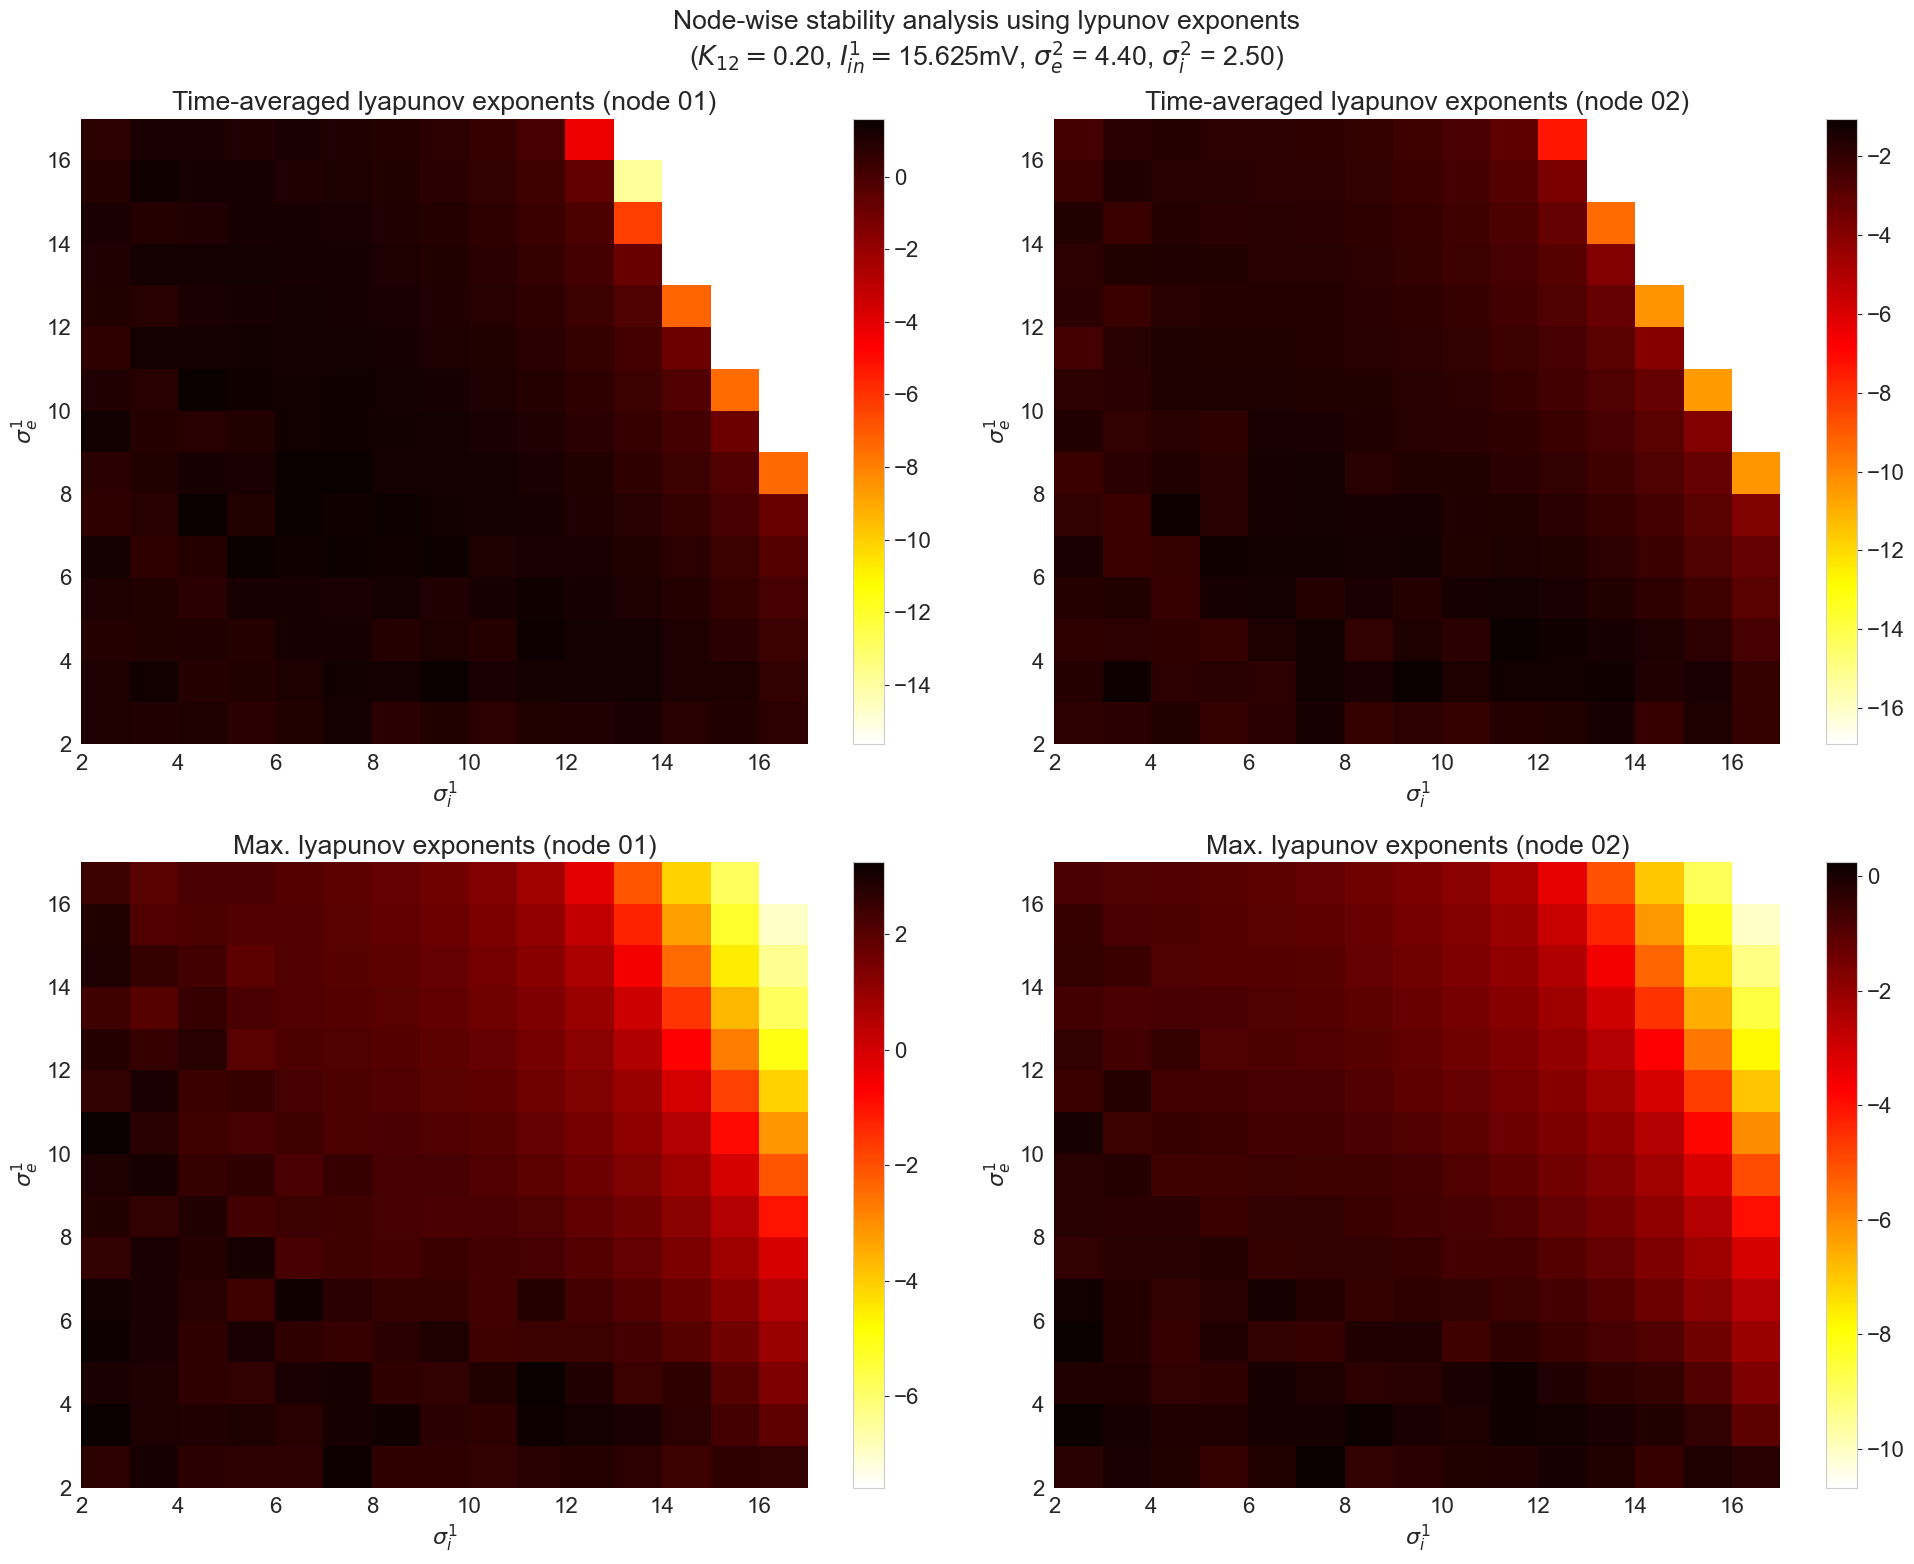

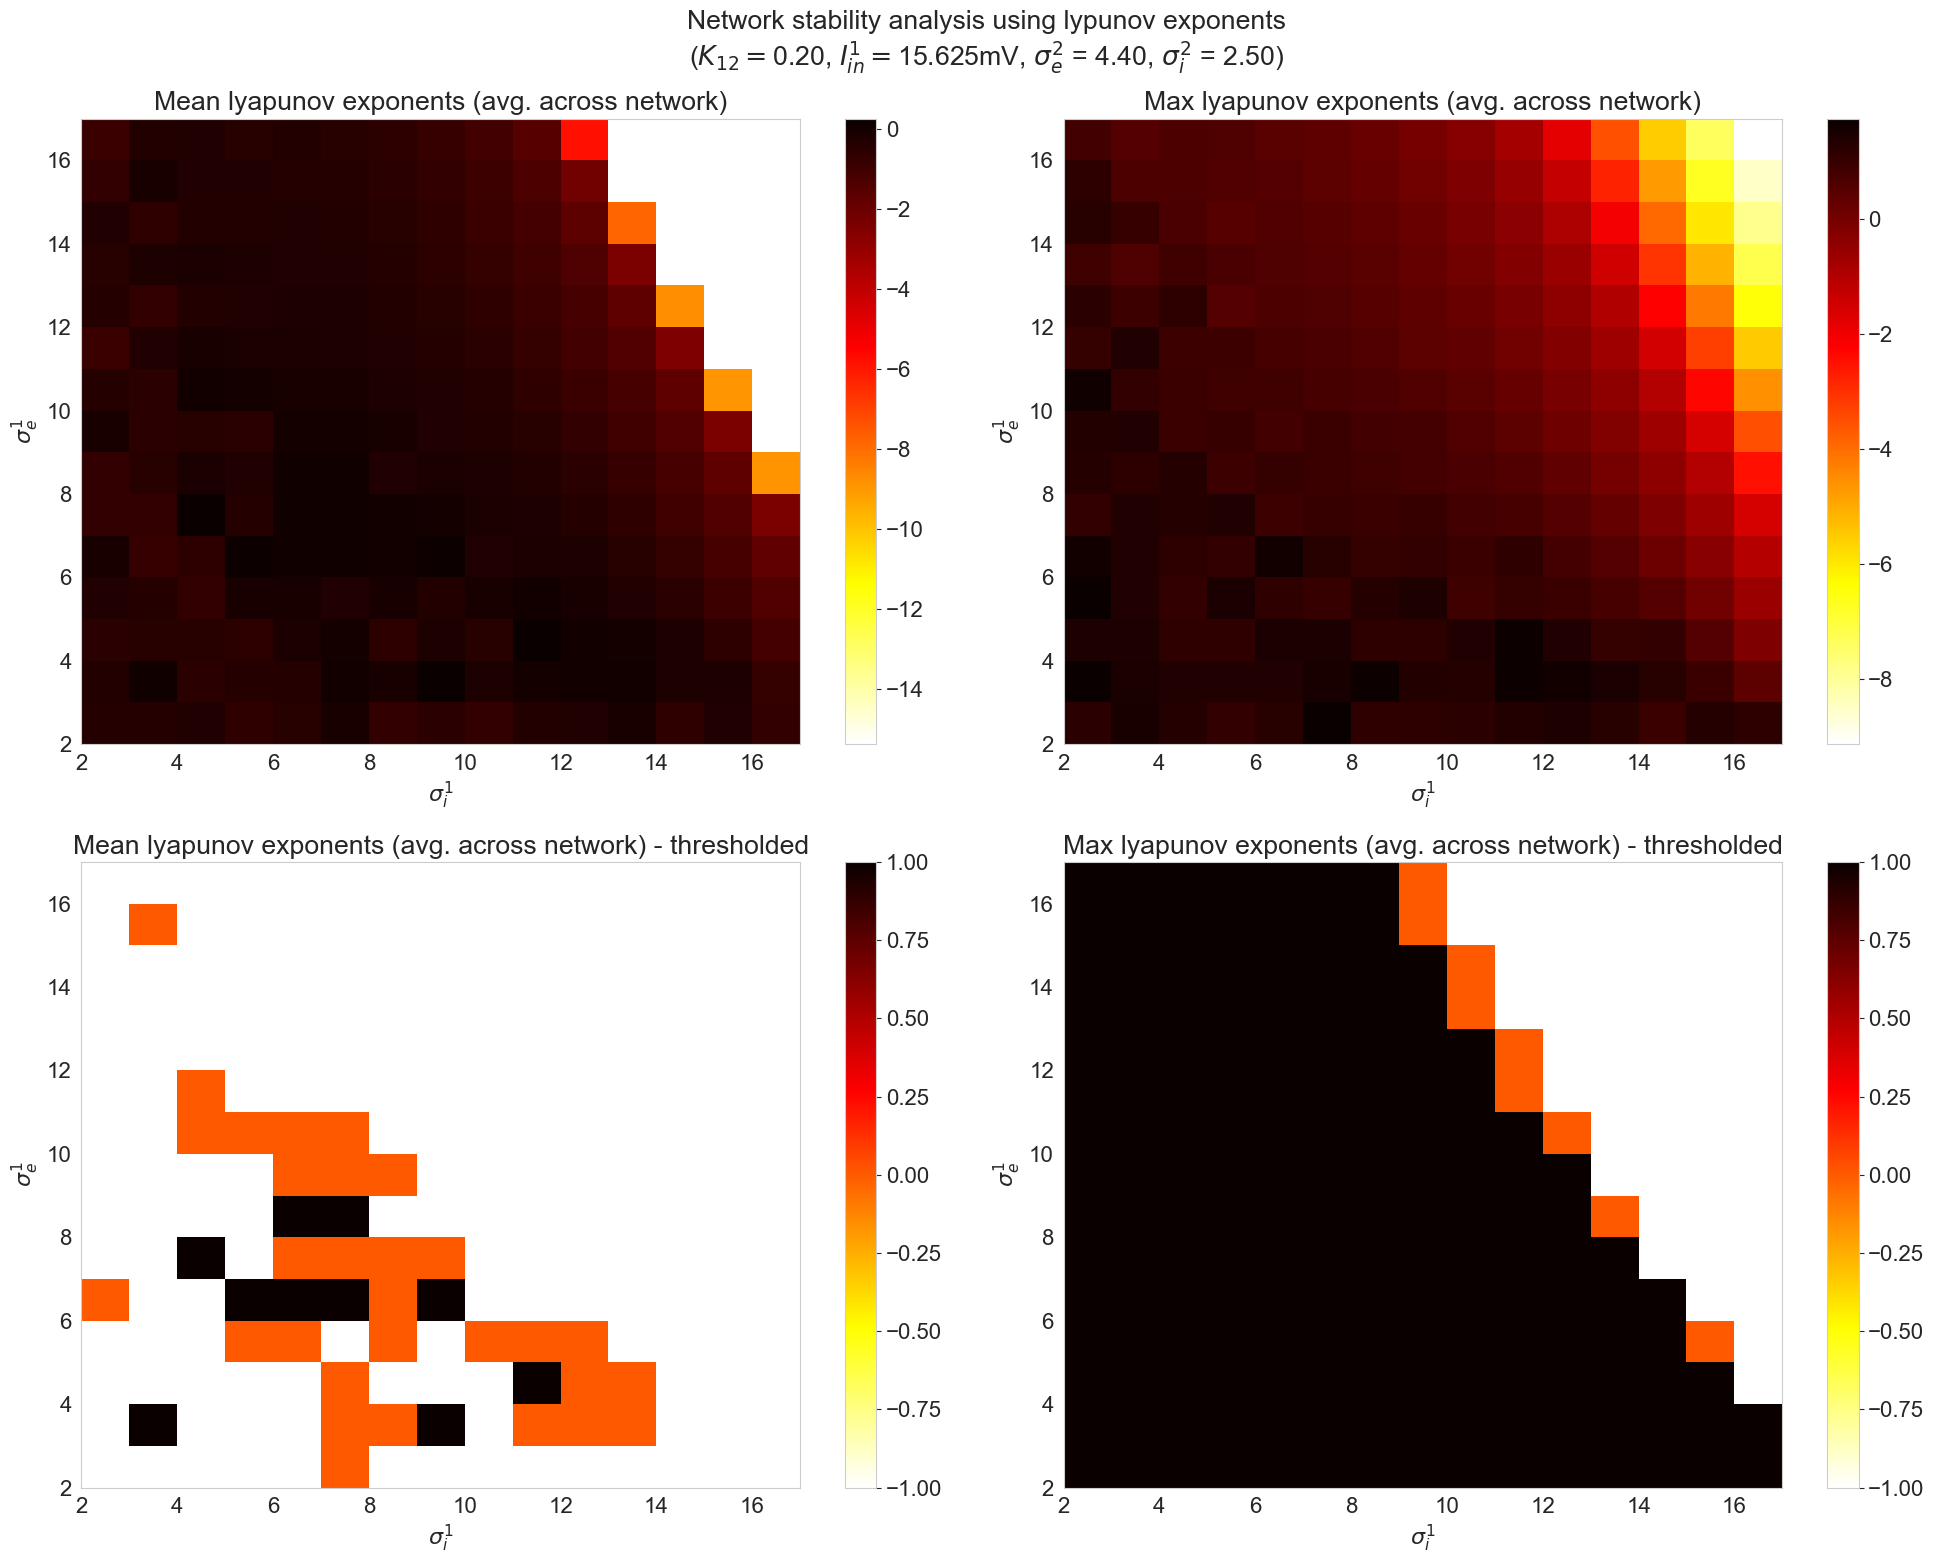

In [17]:
lyap_matrices_e1_i1 = {
                        'n1_mean': lyapunov_n1_mean,
                        'n2_mean': lyapunov_n2_mean,
                        'n1_max': lyapunov_n1_max,
                        'n2_max': lyapunov_n2_max
    }

para_str = r"($K_{12} = $" + f"{params['K']:.2f}, " + r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV, " + \
            r"$\sigma_e^2$ = " + f"{params['sig_e2']:.2f}, " + r"$\sigma_i^2$ = " + f"{params['sig_i2']:.2f})"
plot_opts_dict = {
                    'fig_size': (20, 16),
                    'ylabel': r'$\sigma_e^1$',
                    'xlabel': r'$\sigma_i^1$',
                    'para_str': para_str
}           

plot_lyapunov_nodes(
                    var1_arr = sigma_arr,
                    var2_arr = sigma_arr,
                    plot_opts = plot_opts_dict, 
                    save_dir = save_dir, 
                    if_save = True, 
                    image_name = f'lypunov_node_wise_image_{lyap_node:03d}',
                    **lyap_matrices_e1_i1
                    )

lyap_node += 1

plot_lyapunov_network(
                      var1_arr = sigma_arr, 
                      var2_arr = sigma_arr, 
                      mask_thresh = 0.1, 
                      plot_opts = plot_opts_dict, 
                      save_dir = save_dir, 
                      if_save = True, 
                      image_name = f'lypunov_network_image_{lyap_net:03d}', 
                      **lyap_matrices_e1_i1
                      )

lyap_net += 1

In [18]:
# lyapunov exponenet response maps (changing heterogeneity in node 2)

params['K'] = 0.2
params['sig_e1'] = 4.4
params['sig_i1'] = 2.5

sigma_arr = np.arange(2.5, 17.5, 1)

lyapunov_n1_mean = np.zeros((len(sigma_arr), len(sigma_arr)))
lyapunov_n2_mean = np.zeros((len(sigma_arr), len(sigma_arr)))

lyapunov_n1_max = np.zeros((len(sigma_arr), len(sigma_arr)))
lyapunov_n2_max = np.zeros((len(sigma_arr), len(sigma_arr)))

for e1, sigma_e in enumerate(sigma_arr):
    params['sig_e2'] = sig_e2 = sigma_e
    tic = time.time()
    for i1, sigma_i in enumerate(sigma_arr):
        params['sig_i2'] = sig_i2 = sigma_i

        u = np.zeros((n_trials, 4, T))

        u = euler_intergrate(u, **params)
        
        lyap_node1 = np.log(np.abs(np.diff(np.mean(u[:, 0, 200:], axis = 0))))
        lyap_node2 = np.log(np.abs(np.diff(np.mean(u[:, 2, 200:], axis = 0))))
        
        lyapunov_n1_mean[e1, i1] = np.mean(lyap_node1)
        lyapunov_n2_mean[e1, i1] = np.mean(lyap_node2)
        lyapunov_n1_max[e1, i1] = lyap_node1.max()
        lyapunov_n2_max[e1, i1] = lyap_node2.max()
    toc = time.time()
    print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')

running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
finishing sigma value --> Execution time: 47.616s
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
running euler intergration
finishing sigma value --> Execution time: 46.801s
running euler intergration
running euler intergration
running euler intergration
running e

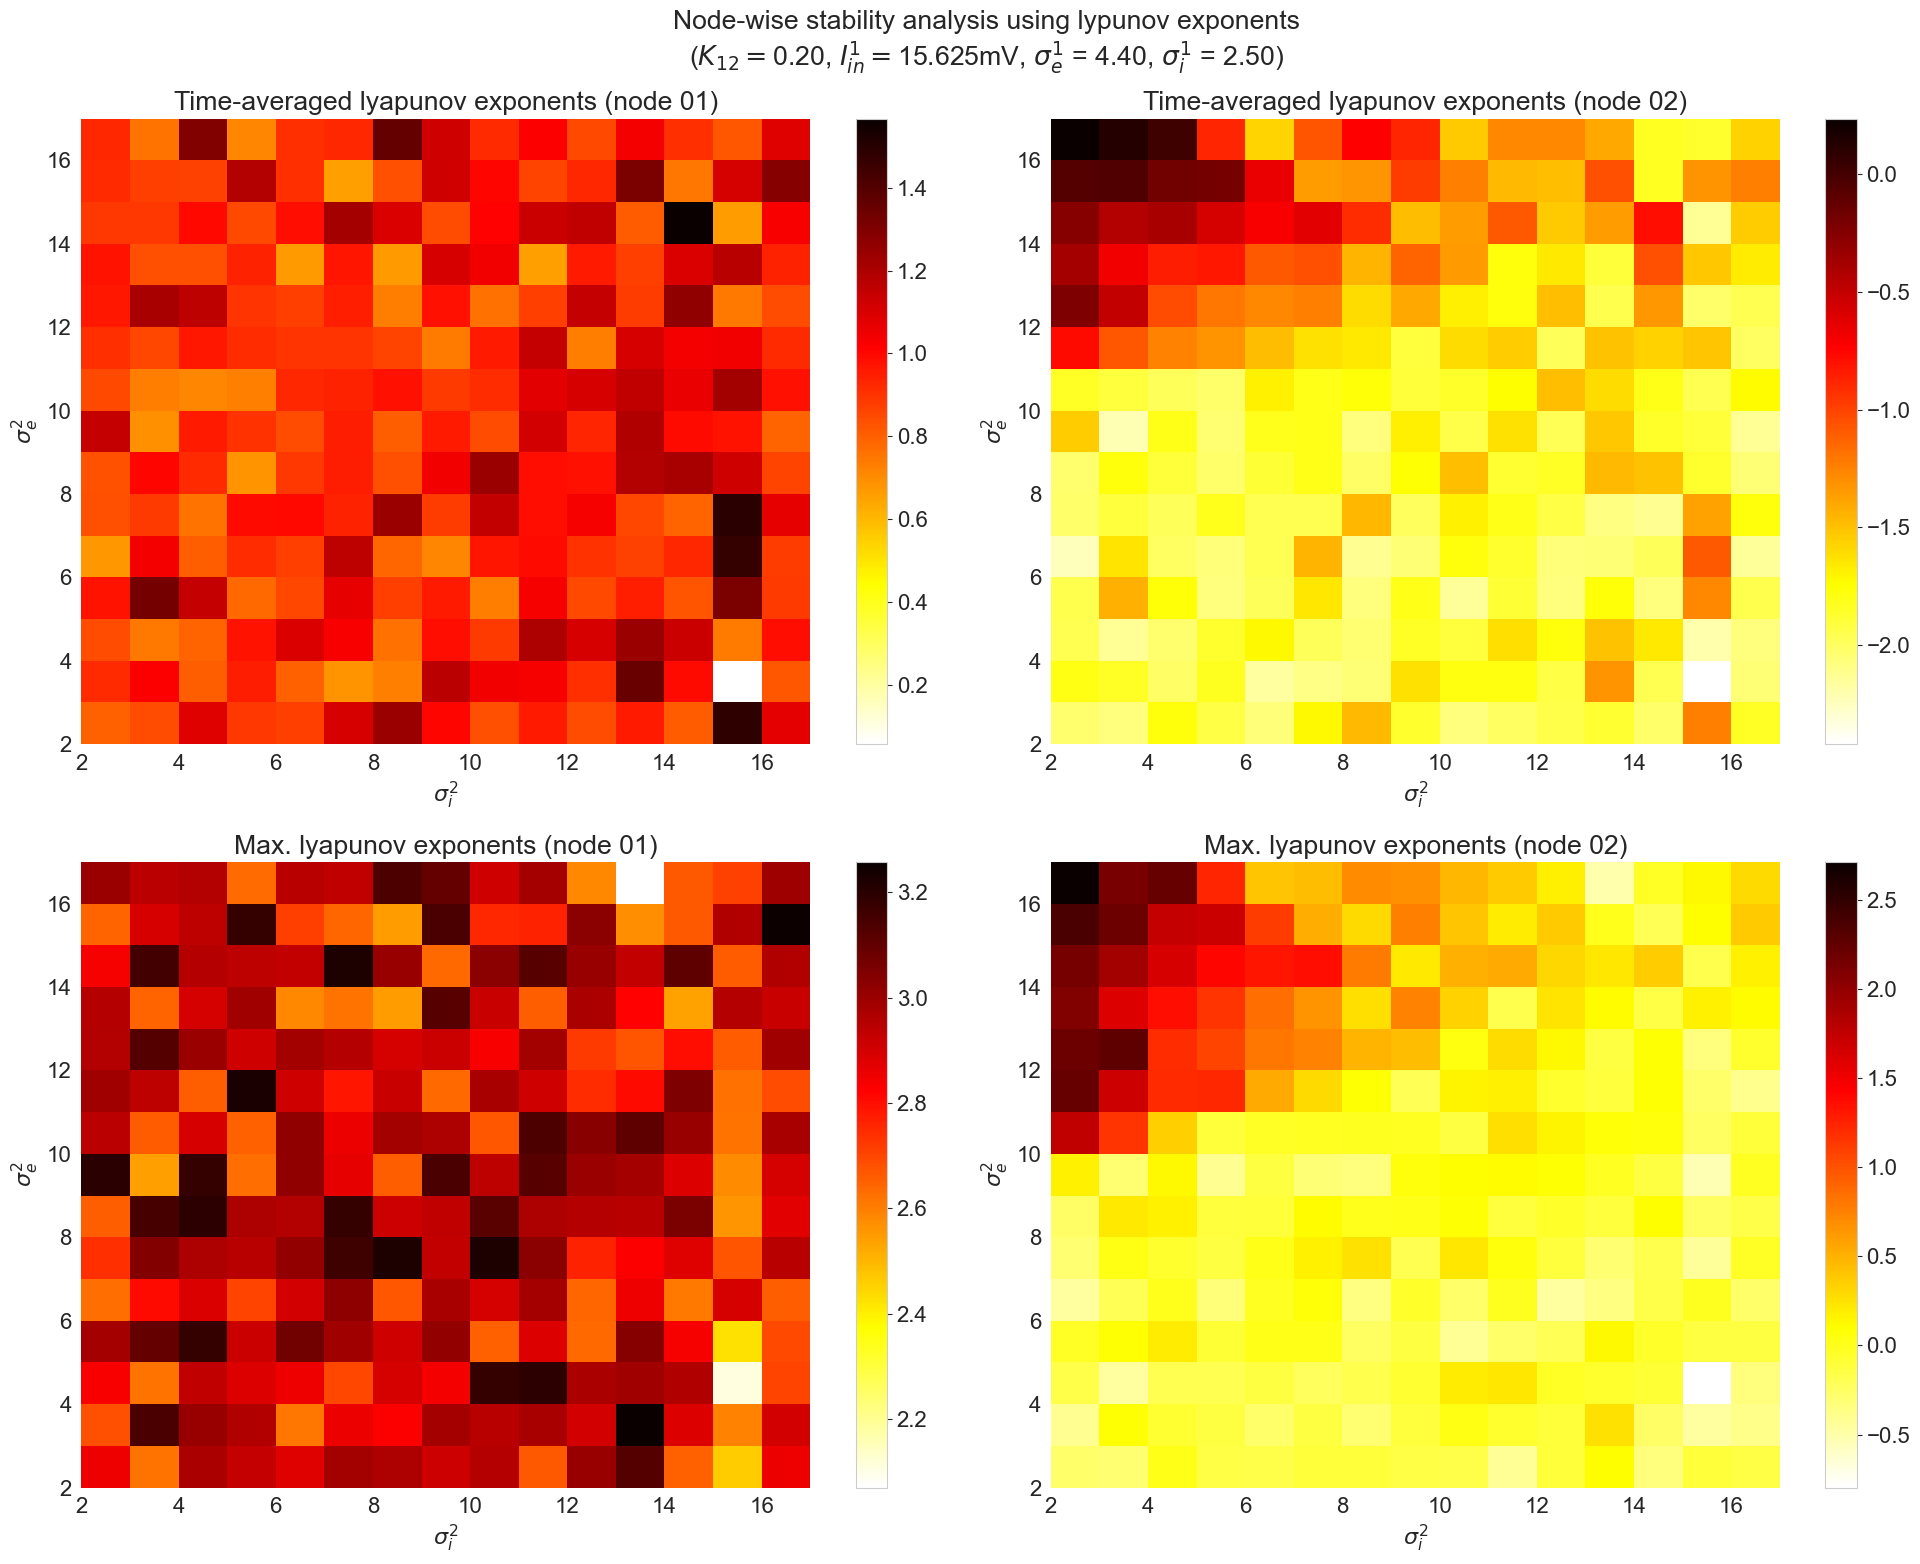

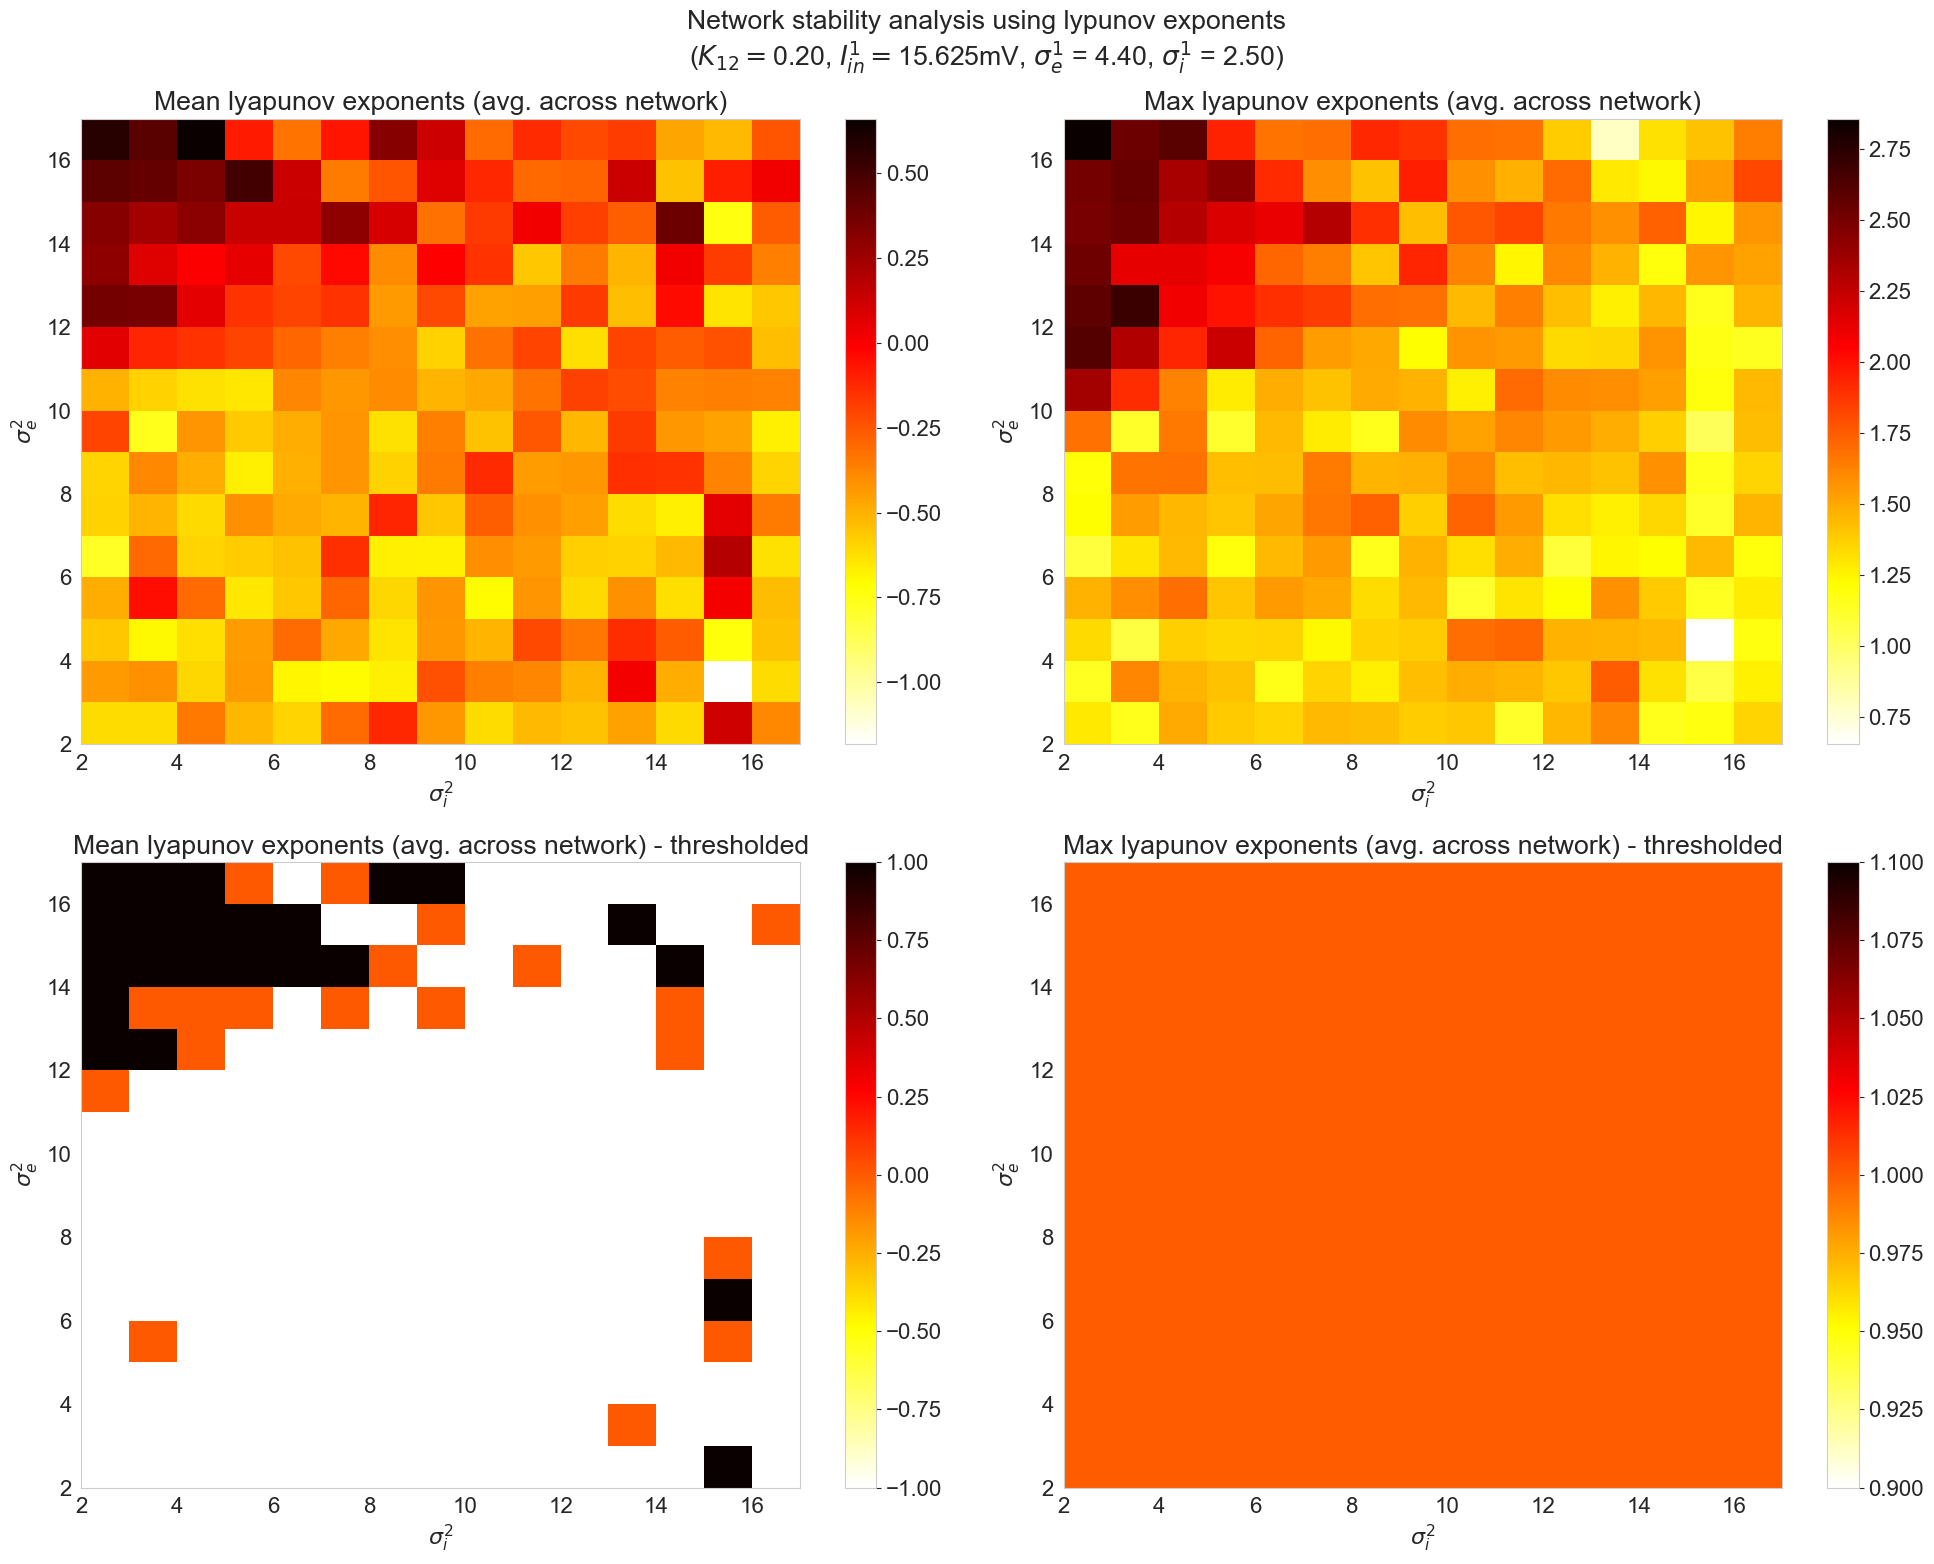

In [19]:
lyap_matrices_e2_i2 = {
                        'n1_mean': lyapunov_n1_mean,
                        'n2_mean': lyapunov_n2_mean,
                        'n1_max': lyapunov_n1_max,
                        'n2_max': lyapunov_n2_max
    }

para_str = r"($K_{12} = $" + f"{params['K']:.2f}, " + r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV, " + \
            r"$\sigma_e^1$ = " + f"{params['sig_e1']:.2f}, " + r"$\sigma_i^1$ = " + f"{params['sig_i1']:.2f})"
plot_opts_dict = {
                    'fig_size': (20, 16),
                    'ylabel': r'$\sigma_e^2$',
                    'xlabel': r'$\sigma_i^2$',
                    'para_str': para_str
}           

plot_lyapunov_nodes(
                    var1_arr = sigma_arr,
                    var2_arr = sigma_arr,
                    plot_opts = plot_opts_dict, 
                    save_dir = save_dir, 
                    if_save = True, 
                    image_name = f'lypunov_node_wise_image_{lyap_node:03d}',
                    **lyap_matrices_e2_i2
                    )

lyap_node += 1

plot_lyapunov_network(
                      var1_arr = sigma_arr, 
                      var2_arr = sigma_arr, 
                      mask_thresh = 0.1, 
                      plot_opts = plot_opts_dict, 
                      save_dir = save_dir, 
                      if_save = True, 
                      image_name = f'lypunov_network_image_{lyap_net:03d}', 
                      **lyap_matrices_e2_i2
                      )

lyap_net += 1